Listing of All Businesses
https://data.lacity.org/Administration-Finance/Listing-of-All-Businesses/r4uk-afju/about_data


## Machine Learning (LSTM)

### Import Library

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

### Data Load & Prep

In [1]:
import pandas as pd
df_cleaned = pd.read_csv('dataset\\business_filtered.csv')

In [2]:
df_cleaned.shape

(515273, 24)

In [3]:
df_cleaned['NAICS-2'] = df_cleaned['NAICS'].map(lambda n: int(n / 10000))

In [4]:
df_naics = pd.read_csv('dataset\\naics_2_clean.csv')
code_sector_dict = df_naics.set_index('Code')['Sector_Title'].to_dict()

In [5]:
df_cleaned['NAICS-2_Title'] = df_cleaned['NAICS-2'].map(code_sector_dict)

In [6]:
print(df_cleaned.columns)

Index(['LOCATION ACCOUNT #', 'BUSINESS NAME', 'DBA NAME', 'STREET ADDRESS',
       'CITY', 'ZIP CODE', 'LOCATION DESCRIPTION', 'MAILING ADDRESS',
       'MAILING CITY', 'MAILING ZIP CODE', 'NAICS',
       'PRIMARY NAICS DESCRIPTION', 'COUNCIL DISTRICT', 'LOCATION START DATE',
       'LOCATION END DATE', 'LOCATION', '5d_zip', '5d_zip_num', 'latitude',
       'longitude', 'start_year', 'start_month', 'is_open', 'duration',
       'NAICS-2', 'NAICS-2_Title'],
      dtype='object')


In [7]:
df_process = df_cleaned[['NAICS-2', 'NAICS-2_Title', 'is_open', 'duration', 'LOCATION START DATE', 'LOCATION END DATE']].copy()
df_process['LOCATION START DATE'] = pd.to_datetime(df_process['LOCATION START DATE'], errors='coerce')
df_process['LOCATION END DATE'] = pd.to_datetime(df_process['LOCATION END DATE'], errors='coerce')


In [8]:
business_count = df_process.groupby('LOCATION START DATE').size().reset_index(name='business_increased')
business_count.sort_values('LOCATION START DATE', inplace=True)
business_count.reset_index(drop=True, inplace=True)
business_count.rename(columns={'LOCATION START DATE': 'date'}, inplace=True)
business_count1 = df_process.groupby('LOCATION END DATE').size().reset_index(name='business_decreased')
business_count1.sort_values('LOCATION END DATE', inplace=True)
business_count1.reset_index(drop=True, inplace=True)
business_count1.rename(columns={'LOCATION END DATE': 'date'}, inplace=True)

In [9]:
business_count = pd.merge(business_count, business_count1, on='date', how='outer')
business_count

,date,business_increased,business_decreased
0,1921-01-01,1.0,NaN
1,1928-09-24,1.0,NaN
2,1929-01-01,1.0,NaN
3,1930-10-30,1.0,NaN
4,1931-01-01,1.0,NaN
...,...,...,...
16575,2025-05-01,1.0,NaN
16576,2025-05-17,2.0,NaN
16577,2025-06-01,1.0,NaN
16578,2025-09-25,NaN,1.0


In [10]:
business_count.fillna(0, inplace=True)
business_count

,date,business_increased,business_decreased
0,1921-01-01,1.0,0.0
1,1928-09-24,1.0,0.0
2,1929-01-01,1.0,0.0
3,1930-10-30,1.0,0.0
4,1931-01-01,1.0,0.0
...,...,...,...
16575,2025-05-01,1.0,0.0
16576,2025-05-17,2.0,0.0
16577,2025-06-01,1.0,0.0
16578,2025-09-25,0.0,1.0


In [11]:
business_count['business_change'] = business_count['business_increased'] - business_count['business_decreased']

In [12]:
business_count['business_number'] = business_count['business_change'].cumsum()

In [13]:
business_count

,date,business_increased,business_decreased,business_change,business_number
0,1921-01-01,1.0,0.0,1.0,1.0
1,1928-09-24,1.0,0.0,1.0,2.0
2,1929-01-01,1.0,0.0,1.0,3.0
3,1930-10-30,1.0,0.0,1.0,4.0
4,1931-01-01,1.0,0.0,1.0,5.0
...,...,...,...,...,...
16575,2025-05-01,1.0,0.0,1.0,428613.0
16576,2025-05-17,2.0,0.0,2.0,428615.0
16577,2025-06-01,1.0,0.0,1.0,428616.0
16578,2025-09-25,0.0,1.0,-1.0,428615.0


### 
---


### Working on monthly dataset
previous data prep by day, prep for month

In [15]:
def ml_data_prep(df):
    """
    Prepares a time-series dataset for machine learning by computing the monthly net change 
    and cumulative count of businesses based on their start and end dates.
    
    Input Requirements:
      - The DataFrame `df` must include the following columns:
          * 'LOCATION START DATE': Date when a business started.
          * 'LOCATION END DATE'  : Date when a business ended (can contain NaN values).
          
    Processing Steps:
      1. Converts the 'LOCATION START DATE' and 'LOCATION END DATE' columns into year-month format.
      2. Groups the data by the derived 'start_year_month' to count the number of businesses started 
         (business_increased).
      3. Groups the data by the derived 'end_year_month' to count the number of businesses ended 
         (business_decreased).
      4. Sorts each grouped DataFrame by the year-month and resets the index.
      5. Renames the grouping column to a common name 'date' so that the two datasets can be merged.
      6. Merges the two DataFrames on 'date' using an outer join, ensuring all months are included.
      7. Fills any missing values resulting from the merge with 0.
      8. Calculates the net monthly change as the difference between business_increased and business_decreased.
      9. Computes the cumulative total of the net monthly change across time (business_number).
      
    Returns:
      A DataFrame with the following columns:
          - 'date'             : The year-month (string) used for grouping.
          - 'business_increased': Number of businesses started in that month.
          - 'business_decreased': Number of businesses ended in that month.
          - 'business_change'   : The net change for that month 
                                  (business_increased minus business_decreased).
          - 'business_number'   : The cumulative sum of the net monthly change.
    """
    # df data prep to month
    df['start_year_month'] = df['LOCATION START DATE'].dt.strftime('%Y-%m')
    df['end_year_month'] = df['LOCATION END DATE'].dt.strftime('%Y-%m')
    # data process
    df1 = df.groupby('start_year_month').size().reset_index(name='business_increased')
    df1.sort_values('start_year_month', inplace=True)
    df1.reset_index(drop=True, inplace=True)
    df1.rename(columns={'start_year_month': 'date'}, inplace=True)
    df2 = df.groupby('end_year_month').size().reset_index(name='business_decreased')
    df2.sort_values('end_year_month', inplace=True)
    df2.reset_index(drop=True, inplace=True)
    df2.rename(columns={'end_year_month': 'date'}, inplace=True)
    # merge
    business_count = pd.merge(df1, df2, on='date', how='outer')
    # handling missing value with 0
    business_count.fillna(0, inplace=True)

    business_count['business_change'] = business_count['business_increased'] - business_count['business_decreased']
    business_count['business_number'] = business_count['business_change'].cumsum()
    return business_count

In [16]:
monthly_counts = ml_data_prep(df_process)

In [17]:
monthly_counts

,date,business_increased,business_decreased,business_change,business_number
0,1921-01,1.0,0.0,1.0,1.0
1,1928-09,1.0,0.0,1.0,2.0
2,1929-01,1.0,0.0,1.0,3.0
3,1930-10,1.0,0.0,1.0,4.0
4,1931-01,1.0,0.0,1.0,5.0
...,...,...,...,...,...
961,2025-03,7.0,0.0,7.0,428612.0
962,2025-05,3.0,0.0,3.0,428615.0
963,2025-06,1.0,0.0,1.0,428616.0
964,2025-09,0.0,1.0,-1.0,428615.0


In [18]:
def filter_by_date_range(df, min_year_month, max_year_month):
    """
    Filters a DataFrame to include only rows with dates between min_year_month and max_year_month (inclusive).
    
    Parameters:
      - df (pd.DataFrame): The input DataFrame that contains a 'date' column. This column can be in string format ("YYYY-MM")
                           or already as datetime objects.
      - min_year_month (str): The minimum year-month in "YYYY-MM" format. Rows with dates before this month are excluded.
      - max_year_month (str): The maximum year-month in "YYYY-MM" format. Rows with dates after this month are excluded.
      
    Returns:
      - pd.DataFrame: A filtered DataFrame containing only rows where the 'date' column is within the specified range.
    """
    # Make a copy of the dataframe to avoid modifying the original DataFrame
    df = df.copy()

    # Ensure the 'date' column is in datetime format (assume day=1 for monthly data)
    df['date_dt'] = pd.to_datetime(df['date'], format='%Y-%m', errors='coerce')
    
    # Convert the provided minimum and maximum boundaries to datetime objects
    min_dt = pd.to_datetime(min_year_month, format='%Y-%m')
    max_dt = pd.to_datetime(max_year_month, format='%Y-%m')
    
    # Filter the DataFrame to the specified date range (inclusive)
    filtered_df = df[(df['date_dt'] >= min_dt) & (df['date_dt'] <= max_dt)].copy()
    
    # Optionally, drop the helper datetime column if it is not needed
    filtered_df.drop(columns='date_dt', inplace=True)
    
    return filtered_df

In [19]:
monthly_counts_filtered = filter_by_date_range(monthly_counts, '1980-01', '2025-01')

In [20]:
monthly_counts_filtered

,date,business_increased,business_decreased,business_change,business_number
419,1980-01,277.0,0.0,277.0,11612.0
420,1980-02,78.0,0.0,78.0,11690.0
421,1980-03,81.0,0.0,81.0,11771.0
422,1980-04,61.0,0.0,61.0,11832.0
423,1980-05,59.0,0.0,59.0,11891.0
...,...,...,...,...,...
955,2024-09,557.0,24.0,533.0,427029.0
956,2024-10,644.0,21.0,623.0,427652.0
957,2024-11,505.0,28.0,477.0,428129.0
958,2024-12,269.0,39.0,230.0,428359.0


### 
---


### Prep data for ml

In [21]:
import numpy as np

import matplotlib.pyplot as plt
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [22]:
# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(monthly_counts_filtered['business_number'].values.reshape(-1,1))

In [23]:
# Set the number of month used for prediction
prediction_n = 3

# Initialize empty lists for training data input and output
x_train = []
y_train = []

# Iterate through the scaled data, starting from the prediction_n index
for x in range(prediction_n, len(scaled_data)):
    # Append the previous 'prediction_n' values to x_train
    x_train.append(scaled_data[x - prediction_n: x, 0])
    # Append the current value to y_train
    y_train.append(scaled_data[x, 0])

# Convert the x_train and y_train lists to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape x_train to a 3D array with the appropriate dimensions for the LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

### 
---


### LSTM model

In [24]:
def LSTM_model(x_train_shape):
    # Initialize a sequential model
    model = Sequential()
    model.add(Input(shape=(x_train_shape[1], 1)))
    # Add the 1st LSTM layer with 64 units, input shape, and return sequences
    # model.add(LSTM(units=64, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(LSTM(units=64, return_sequences=True))
    # Add dropout to prevent overfitting
    model.add(Dropout(0.2))

    # Add a 2nd LSTM layer with 64 units and return sequences
    model.add(LSTM(units=64, return_sequences=True))
    # Add dropout to prevent overfitting
    model.add(Dropout(0.2))

    # Add a 3rd LSTM layer with 64 units and return sequences
    model.add(LSTM(units=64, return_sequences=True))
    # Add dropout to prevent overfitting
    model.add(Dropout(0.2))

    # Add a 4th LSTM layer with 64 units
    model.add(LSTM(units=64))
    # Add dropout to prevent overfitting
    model.add(Dropout(0.2))

    # Add a dense output layer with one unit
    model.add(Dense(units=1))

    return model

In [25]:
model = LSTM_model(x_train.shape)
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 3, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size = 32
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.1717
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0672
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0120
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0060
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0035
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0029
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0021
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0023
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0023
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0021
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0021
Epoch 13/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0018
Epoch 14/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0023
Epoch 15/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021
Epo

### Test

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step


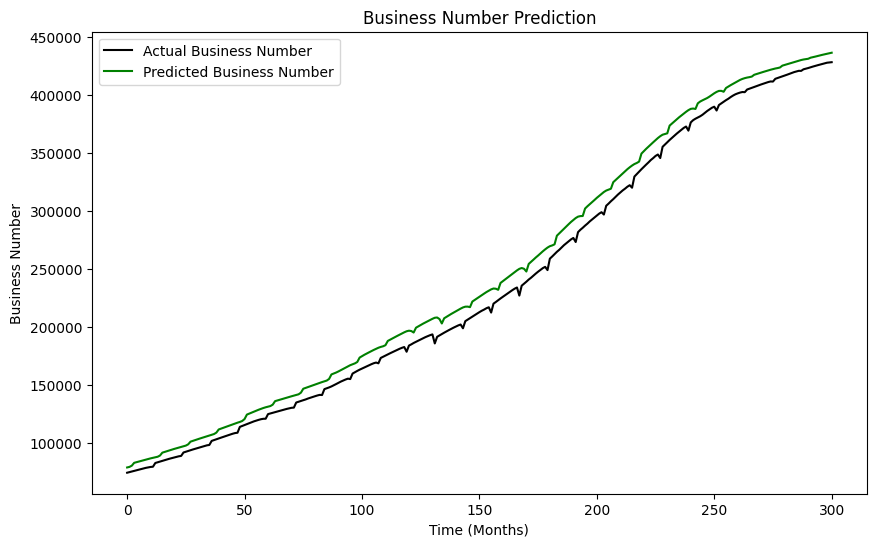

In [27]:
prediction_n = 3
START_DATE_TEST = '2000-01'  # Define the test start date (adjust as needed)

# Ensure the 'date' column is converted to datetime for filtering
monthly_counts_filtered['date_dt'] = pd.to_datetime(monthly_counts_filtered['date'], format='%Y-%m')

# --- 1. Prepare the test data portion ---
# Filter the test data: all records from the specified test start date onward.
test_data = monthly_counts_filtered[monthly_counts_filtered['date_dt'] >= pd.to_datetime(START_DATE_TEST, format='%Y-%m')].copy()
# Extract the actual business_number values (for plotting later)
actual_business_number = test_data['business_number'].values

# Optionally, define training data as those records before the test start date.
train_data = monthly_counts_filtered[monthly_counts_filtered['date_dt'] < pd.to_datetime(START_DATE_TEST, format='%Y-%m')].copy()

# --- 2. Create the dataset for predictions ---
# Concatenate the business_number column from the training and test data.
# (This is used to create the proper input window for predictions.)
total_dataset = pd.concat((train_data['business_number'], test_data['business_number']), axis=0)

# Extract the portion used for generating test sequences:
# We need the last (len(test_data) + prediction_n) months from the total dataset.
model_inputs = total_dataset.values[ len(total_dataset) - len(test_data) - prediction_n : ]
model_inputs = model_inputs.reshape(-1, 1)

# Scale the model inputs using the scaler fitted on the training data.
model_inputs = scaler.transform(model_inputs)

# --- 3. Create test input sequences for the LSTM ---
x_test = []
for i in range(prediction_n, len(model_inputs)):
    # For each time step, select the previous 'prediction_n' values as one sample.
    x_test.append(model_inputs[i-prediction_n:i, 0])

x_test = np.array(x_test)
# Reshape x_test to a 3D array [samples, timesteps, features], needed for LSTM:
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# --- 4. Make predictions using the LSTM model ---
predicted_business_number = model.predict(x_test)
# Invert the scaling to obtain the actual predicted values:
predicted_business_number = scaler.inverse_transform(predicted_business_number)

# --- 5. Plot the results ---
plt.figure(figsize=(10, 6))
plt.plot(actual_business_number, color='black', label="Actual Business Number")
plt.plot(predicted_business_number, color='green', label="Predicted Business Number")
plt.title("Business Number Prediction")
plt.xlabel("Time (Months)")
plt.ylabel("Business Number")
plt.legend()
plt.show()

#### Conclusion
Looks ok so far.

### 
---

### Try to apply to specific industry (Retail)

In [28]:
df_cleaned = pd.read_csv('dataset\\business_filtered.csv')
df_cleaned['NAICS-2'] = df_cleaned['NAICS'].map(lambda n: int(n / 10000))
df_naics = pd.read_csv('dataset\\naics_2_clean.csv')
code_sector_dict = df_naics.set_index('Code')['Sector_Title'].to_dict()
df_cleaned['NAICS-2_Title'] = df_cleaned['NAICS-2'].map(code_sector_dict)
df_process = df_cleaned[['NAICS-2', 'NAICS-2_Title', 'is_open', 'duration', 'LOCATION START DATE', 'LOCATION END DATE']].copy()
df_process['LOCATION START DATE'] = pd.to_datetime(df_process['LOCATION START DATE'], errors='coerce')
df_process['LOCATION END DATE'] = pd.to_datetime(df_process['LOCATION END DATE'], errors='coerce')

In [29]:
df_retail = df_process[df_process['NAICS-2_Title'] == 'Retail Trade']

In [30]:
data_retail = ml_data_prep(df_retail)

C:\Users\Eric\AppData\Local\Temp\ipykernel_35688\56330774.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_year_month'] = df['LOCATION START DATE'].dt.strftime('%Y-%m')
C:\Users\Eric\AppData\Local\Temp\ipykernel_35688\56330774.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_year_month'] = df['LOCATION END DATE'].dt.strftime('%Y-%m')


In [31]:
month_min = '1980-01'
month_max = '2025-01'
data_retail_filtered = filter_by_date_range(data_retail, month_min, month_max)

#### data prep

In [32]:
# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data_retail_filtered['business_number'].values.reshape(-1,1))

In [33]:
# Set the number of month used for prediction
prediction_n = 3

# Initialize empty lists for training data input and output
x_train = []
y_train = []

# Iterate through the scaled data, starting from the prediction_n index
for x in range(prediction_n, len(scaled_data)):
    # Append the previous 'prediction_n' values to x_train
    x_train.append(scaled_data[x - prediction_n: x, 0])
    # Append the current value to y_train
    y_train.append(scaled_data[x, 0])

# Convert the x_train and y_train lists to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape x_train to a 3D array with the appropriate dimensions for the LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [40]:
# same LSTM model 4 layers
def LSTM_model(x_train_shape):
    # Initialize a sequential model
    model = Sequential()
    model.add(Input(shape=(x_train_shape[1], 1)))
    # Add the 1st LSTM layer with 128 units, input shape, and return sequences
    model.add(LSTM(units=128, return_sequences=True))
    # Add dropout to prevent overfitting
    model.add(Dropout(0.2))

    # Add a 2nd LSTM layer with 128 units and return sequences
    model.add(LSTM(units=128, return_sequences=True))
    # Add dropout to prevent overfitting
    model.add(Dropout(0.2))

    # Add a 3rd LSTM layer with 128 units and return sequences
    model.add(LSTM(units=128, return_sequences=True))
    # Add dropout to prevent overfitting
    model.add(Dropout(0.2))

    # Add a 4th LSTM layer with 64 units
    model.add(LSTM(units=64))
    # Add dropout to prevent overfitting
    model.add(Dropout(0.2))

    # Add a dense output layer with one unit
    model.add(Dense(units=1))

    return model

In [41]:
model = LSTM_model(x_train.shape)
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 3, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 3, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 3, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 379,201 (1.45 MB)

 Trainable params: 379,201 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

#### training

In [42]:
model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size = 32
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.1517
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0395
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0062
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0041
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0024
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0016
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0018
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0013
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0018


In [44]:
model.save('LSTM_model.keras')

### Test

In [86]:
model = tf.keras.models.load_model('LSTM_model.keras')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


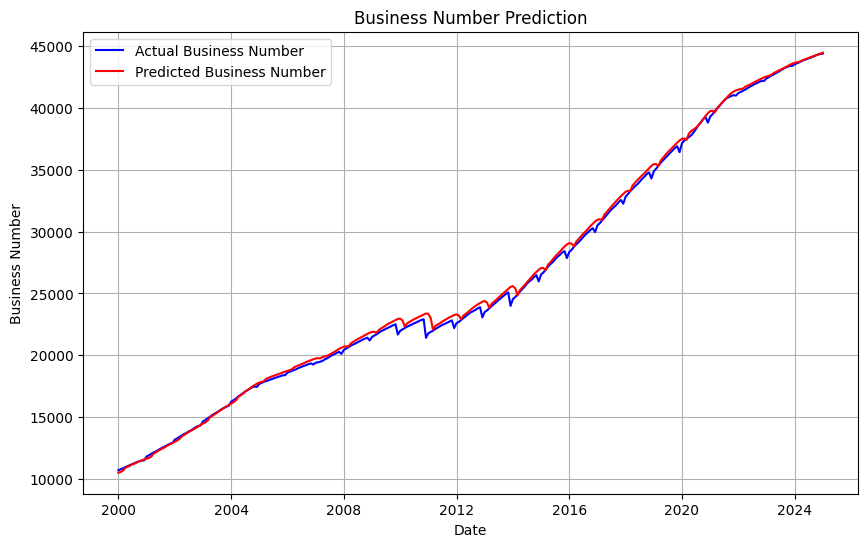

In [ ]:
prediction_n = 3
START_DATE_TEST = '2000-01'  # Define the test start date (adjust as needed)

# Ensure the 'date' column is converted to datetime for filtering
data_retail_filtered['date_dt'] = pd.to_datetime(data_retail_filtered['date'], format='%Y-%m')

# --- 1. Prepare the test data portion ---
# Filter the test data: all records from the specified test start date onward.
test_data = data_retail_filtered[data_retail_filtered['date_dt'] >= pd.to_datetime(START_DATE_TEST, format='%Y-%m')].copy()
# Extract the actual business_number values (for plotting later)
actual_business_number = test_data['business_number'].values

# Optionally, define training data as those records before the test start date.
train_data = data_retail_filtered[data_retail_filtered['date_dt'] < pd.to_datetime(START_DATE_TEST, format='%Y-%m')].copy()

# --- 2. Create the dataset for predictions ---
# Concatenate the business_number column from the training and test data.
# (This is used to create the proper input window for predictions.)
total_dataset = pd.concat((train_data['business_number'], test_data['business_number']), axis=0)

# Extract the portion used for generating test sequences:
# We need the last (len(test_data) + prediction_n) months from the total dataset.
model_inputs = total_dataset.values[ len(total_dataset) - len(test_data) - prediction_n : ]
model_inputs = model_inputs.reshape(-1, 1)

# Scale the model inputs using the scaler fitted on the training data.
model_inputs = scaler.transform(model_inputs)

# --- 3. Create test input sequences for the LSTM ---
x_test = []
for i in range(prediction_n, len(model_inputs)):
    # For each time step, select the previous 'prediction_n' values as one sample.
    x_test.append(model_inputs[i-prediction_n:i, 0])

x_test = np.array(x_test)
# Reshape x_test to a 3D array [samples, timesteps, features], needed for LSTM:
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# --- 4. Make predictions using the LSTM model ---
predicted_business_number = model.predict(x_test)
# Invert the scaling to obtain the actual predicted values:
predicted_business_number = scaler.inverse_transform(predicted_business_number)

# --- 5. Plot the results ---
prediction_dates = test_data['date_dt'].reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.plot(prediction_dates, actual_business_number, color='blue', label="Actual Business Number")
plt.plot(prediction_dates, predicted_business_number, color='red', label="Predicted Business Number")



plt.title("Business Number Prediction")
# plt.xlabel("Time (Months)")
plt.xlabel("Date")
plt.ylabel("Business Number")
plt.grid(True)
plt.legend()
plt.show()

#### Conclusion
I think that's acceptable result 

### Try predict

In [84]:
model = tf.keras.models.load_model('LSTM_model.keras')

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from tensorflow.keras.models import load_model  # or your model defined elsewhere

# -------------------------------
# Setup / Assumptions:
# -------------------------------
# data_retail_filtered: your DataFrame with columns 'date' (YYYY-MM) and 'business_number'
# scaler: a fitted scaler (e.g., MinMaxScaler) used on business_number training data.
# model: your already-trained LSTM model for predicting the business_number.
# prediction_n: the number of months used for prediction (lookback window); e.g., prediction_n = 6

# For demonstration, let's define some example values:
prediction_n = 3   # e.g., last 3 months for lookback

# -------------------------------
# Prepare the training data (for context)
# -------------------------------
# Scale the business_number column:
scaled_data = scaler.fit_transform(data_retail_filtered['business_number'].values.reshape(-1, 1))

# (Your training preparation code would create x_train and y_train here.)
# For future prediction, we only need the scaled series stored in model_inputs.

# Let's assume your entire series used for training is in 'scaled_data'
# and the corresponding unscaled DataFrame is data_retail_filtered.
# We'll treat model_inputs as the scaled business_number series:
model_inputs = scaled_data

# -------------------------------
# Define the future forecast period: from 2025 to 2027
# -------------------------------
# Convert the 'date' column to datetime:
data_retail_filtered['date_dt'] = pd.to_datetime(data_retail_filtered['date'], format='%Y-%m')
# Assume the latest date in our dataset is the last available month
last_date = data_retail_filtered['date_dt'].max()

# Set the target forecast end date (here December 2027)
target_end_date = pd.to_datetime("2027-12", format='%Y-%m')

# Create a date range for each future month after the last date in the dataset
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), end=target_end_date, freq='MS')
future_steps = len(future_dates)

# -------------------------------
# Iterative Prediction for Future Months
# -------------------------------
# Start with the last 'prediction_n' months from your model inputs:
current_sequence = model_inputs[-prediction_n:].copy()
future_predictions = []

for _ in range(future_steps):
    # Reshape to a 3D array: (1, prediction_n, 1)
    current_seq_reshaped = current_sequence.reshape(1, prediction_n, 1)
    
    # Generate a prediction using the LSTM model:
    pred_scaled = model.predict(current_seq_reshaped)
    
    # Append prediction to our results list:
    future_predictions.append(pred_scaled[0, 0])
    
    # Append the prediction to the end of the current sequence and drop the first value
    current_sequence = np.append(current_sequence, pred_scaled)[-prediction_n:]

# Convert predictions to numpy array and inverse scale to get actual values:
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions_actual = scaler.inverse_transform(future_predictions)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

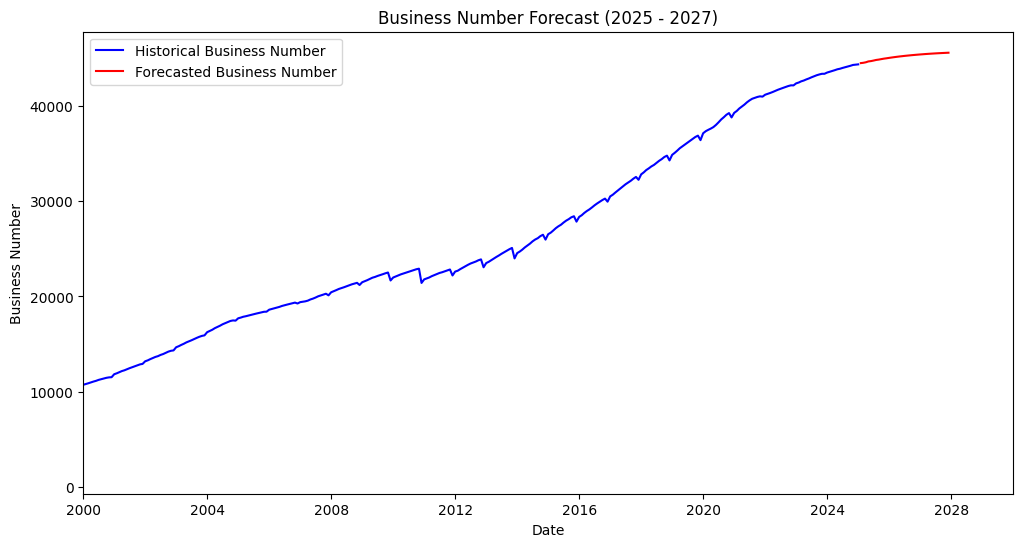

In [95]:
# -------------------------------
# Plot the predictions for the future period
# -------------------------------
plt.figure(figsize=(12, 6))

# Plot actual historical business_number (if desired):
plt.plot(data_retail_filtered['date_dt'], data_retail_filtered['business_number'], color='blue', label='Historical Business Number')

# Plot the forecasted business_number for the future period:
plt.plot(future_dates, future_predictions_actual, color='red', label='Forecasted Business Number')

plt.title("Business Number Forecast (2025 - 2027)")
plt.xlabel("Date")
plt.xlim(pd.to_datetime("2000-01"), pd.to_datetime("2030-01"))
plt.ylabel("Business Number")
plt.legend()
plt.show()

### 
---

## 
---

## Machine Learning (Random Survival Forest)

### Data Organization

In [48]:
import pandas as pd
from datetime import datetime

# Load the dataset
file_path = 'dataset/Listing_of_All_Businesses_20250202.csv'
df = pd.read_csv(file_path)

# Convert date columns to datetime
df['LOCATION START DATE'] = pd.to_datetime(df['LOCATION START DATE'], errors='coerce')
df['LOCATION END DATE'] = pd.to_datetime(df['LOCATION END DATE'], errors='coerce')

# Drop rows with missing critical features (except end date)
df = df.dropna(subset=['NAICS', 'COUNCIL DISTRICT', 'LOCATION START DATE'])

# Handle ongoing businesses: set today's date as LOCATION END DATE where it's missing
today = pd.to_datetime(datetime.today().date())
df['LOCATION END DATE'] = df['LOCATION END DATE'].fillna(today)

# Remove any invalid rows where END < START
df = df[df['LOCATION END DATE'] >= df['LOCATION START DATE']]

# Calculate lifespan in months
df['DURATION_MONTHS'] = (df['LOCATION END DATE'] - df['LOCATION START DATE']).dt.days / 30.44

# Create EVENT column: 1 = closed, 0 = still open
df['EVENT'] = (df['LOCATION END DATE'] != today).astype(int)

# Reset index
df = df.reset_index(drop=True)

# Save cleaned dataset for RSF modeling
df.to_csv('dataset/Cleaned_for_RSF.csv', index=False)
print("Cleaned dataset for RSF saved as 'Cleaned_for_RSF.csv'")

Cleaned dataset for RSF saved as 'Cleaned_for_RSF.csv'


In [53]:
import pandas as pd

# Load the RSF-ready dataset
df_rsf = pd.read_csv('dataset/Cleaned_for_RSF.csv', usecols=['NAICS', 'LOCATION START DATE', 'LOCATION END DATE', 'DURATION_MONTHS', 'EVENT'])

# Show number of rows
print("Number of rows:", df_rsf.shape[0])


Number of rows: 624345


### Data Load & Prep

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_ipcw, cumulative_dynamic_auc
from sksurv.nonparametric import kaplan_meier_estimator

# Load your cleaned dataset
df_rsf = pd.read_csv('dataset/Cleaned_for_RSF.csv', usecols=['NAICS', 'LOCATION START DATE', 'LOCATION END DATE', 'DURATION_MONTHS', 'EVENT'])

# df = df.sample(n=60000, random_state=42)

# Convert dates
df['LOCATION START DATE'] = pd.to_datetime(df['LOCATION START DATE'], errors='coerce')
df['LOCATION END DATE'] = pd.to_datetime(df['LOCATION END DATE'], errors='coerce')

# Event column: True if business is closed (has end date), False otherwise
df['event'] = ~df['LOCATION END DATE'].isna()

# Duration column: For open businesses, use today's date
today = pd.Timestamp.today()
df['duration'] = (
    (df['LOCATION END DATE'].fillna(today) - df['LOCATION START DATE']).dt.days / 30.44
)

# Features
df['Start_Year'] = df['LOCATION START DATE'].dt.year
df['Start_Month'] = df['LOCATION START DATE'].dt.month
df['NAICS_Code'] = df['NAICS'].astype(str).str[:2].astype(int)
df['Council_District'] = df['COUNCIL DISTRICT'].astype(int)

In [55]:
# Step 2: Prepare Features and Survival Labels
X = df[['Start_Year', 'Start_Month', 'Council_District', 'NAICS_Code']]
y = Surv.from_arrays(event=df['event'], time=df['duration'])

# Step 3: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1024)

In [73]:
# Step 4: RSF Model
rsf = RandomSurvivalForest(
    n_estimators=6,
    max_depth=5,
    min_samples_split=100,
    min_samples_leaf=50,
    max_features="sqrt",
    n_jobs=-1,
    random_state=1024
)

In [74]:
# fit model
rsf.fit(X_train, y_train)

RandomSurvivalForest(max_depth=5, min_samples_leaf=50, min_samples_split=100,
                     n_estimators=6, n_jobs=-1, random_state=1024)

In [ ]:
cindex = rsf.score(X_test, y_test)
print(f"Concordance Index (C-index): {cindex:.4f}\n")

In [75]:
import joblib

joblib.dump(rsf, "random_survival_forest_model.pkl")

['random_survival_forest_model.pkl']

In [66]:
# Step 5: Define Prediction Function
def predict_survival_function(model, start_year, start_month, council_district, naics_code, time_points=[6, 12, 36]):
    user_input = pd.DataFrame([{
        "Start_Year": start_year,
        "Start_Month": start_month,
        "Council_District": council_district,
        "NAICS_Code": int(str(naics_code)[:2])
    }])

    surv_func = model.predict_survival_function(user_input, return_array=False)[0]

    print("Predicted survival probabilities:")
    for t in time_points:
        prob = float(surv_func(t)) if t <= surv_func.x[-1] else np.nan
        if not np.isnan(prob):
            print(f"Probability of surviving at least {t} months: {prob:.2%}")
        else:
            print(f"Beyond prediction range at {t} months")

    plt.step(surv_func.x[surv_func.x <= 60], surv_func.y[surv_func.x <= 60], where="post")
    plt.title("Predicted Survival Curve")
    plt.xlabel("Months")
    plt.xlim(6, 60)
    plt.xticks(np.arange(6, 61, 6))
    plt.ylabel("Survival Probability")
    plt.grid(True)
    plt.show()




def interactive_prediction():
    print("Predict Business Survival Probability")
    try:
        start_year = int(input("Enter Start Year (e.g., 2026): "))
        start_month = int(input("Enter Start Month (1–12): "))
        council_district = int(input("Enter Council District (0–15): "))
        naics_code = int(input("Enter NAICS Code (first 2 digits, e.g., 44): "))



        # Call prediction function
        predict_survival_function(
            rsf,
            start_year=start_year,
            start_month=start_month,
            council_district=council_district,
            naics_code=naics_code,
            #time_points=time_points
        )
    except ValueError as e:
        print("Invalid input. Please enter valid numeric values.")



Predict Business Survival Probability
Predicted survival probabilities:
Probability of surviving at least 6 months: 41.67%
Probability of surviving at least 12 months: 18.71%
Probability of surviving at least 36 months: 0.00%


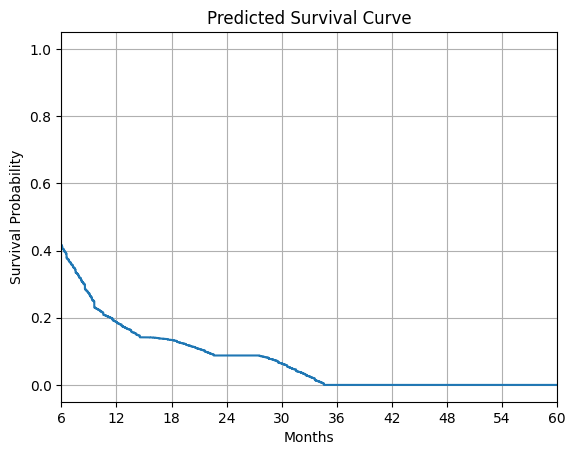

In [76]:
interactive_prediction()

## 
---